# Notebook Statapp

# Phishing emails classifier

## Librairies

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np

## Classifier data

https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset

In [2]:
path = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")

Making a directory story the data inside of working directory

In [40]:
#!mkdir data 

Data is somewhere on the computer so we locate them and bring them back in the working directory

In [42]:
for file in os.listdir(path):
    shutil.move(path+'/'+file,'data')

Merging all files into one big data frame

In [2]:
dfs=[]
for df in os.listdir('data'):
    dfs.append('data'+'/'+df)

dfs=list(map(lambda path:pd.read_csv(path),dfs))
dfs[5].rename(columns={"text_combined":"body"},inplace=True)

In [70]:
df=pd.concat(dfs)

In [71]:
df.sample(n=10)

,sender,receiver,date,subject,body,urls,label
28789,NaN,NaN,NaN,NaN,employment application dear sir madam good day...,NaN,1
17915,NaN,NaN,NaN,NaN,women care size women care size seen tv expand...,NaN,1
5881,NaN,NaN,NaN,NaN,london contact number hi anita arrived yesterd...,NaN,0
70487,NaN,NaN,NaN,NaN,cramer perfect score organ enhancement product...,NaN,1
8067,NaN,NaN,NaN,NaN,lacima energy weather derivatives courses clew...,NaN,0
2332,NaN,NaN,NaN,prior month misnomination,"daren - - - - for 4 / 21 - 4 / 22 , deal # 237...",NaN,0
49885,NaN,NaN,NaN,NaN,stefania montani eotnxkbjmfnunipmnit dear coll...,NaN,0
20473,NaN,NaN,NaN,NaN,monte jacob mary sat moment would sure louisa ...,NaN,1
7926,NaN,NaN,NaN,NaN,fw wharton resume submission summer intern kri...,NaN,0
8811,NaN,NaN,NaN,re : address,"shirley ,\r\nthey are from the uk , arthur and...",NaN,0


Counting fake vs true

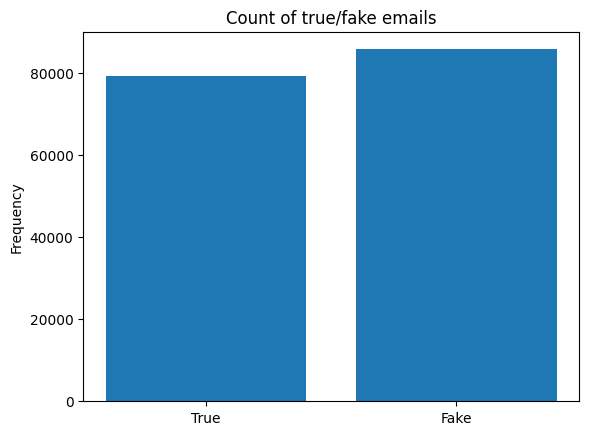

In [49]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [120]:
import unicodedata



def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = unicodedata.normalize("NFKC", text)  # Normalize characters
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_63335/414791656.py:10: SyntaxWarning: invalid escape sequence '\['
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_63335/414791656.py:10: SyntaxWarning: invalid escape sequence '\S'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_63335/414791656.py:10: SyntaxWarning: invalid escape sequence '\w'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.

In [121]:
df['body']=df['body'].apply(lambda s:clean_text(s))

In [8]:
df.sample(n=10)['body']

63216    library congress locservicegovdeliverycom new ...
5470     proposal christie thanks helping attached one ...
685      think there s nothing new on the internet  thi...
45633    mary boucher lisanomenclatureelderwednesdaysha...
1366     dear jose   some incoming messages were undeli...
14460    shoot cu drink increase sperm volume orgasm le...
25534    sap splash july lst project apollo beyond laun...
63456    brant bright milfordsuggestivecomptondmozorg s...
15903    start date        hourahead hour    no ancilla...
60672    virgil lucas marionmenialbeckdocbookorg impres...
Name: body, dtype: object

#### Stopwords + Stemming

removing stopwords and applying stemming method to text

In [93]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_stem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_stem)

100%|██████████| 164972/164972 [01:11<00:00, 2320.47it/s]


To make data manipulation easier

In [116]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

## Descriptive statistics/visualisations

### Wordclouds

(-0.5, 399.5, 199.5, -0.5)

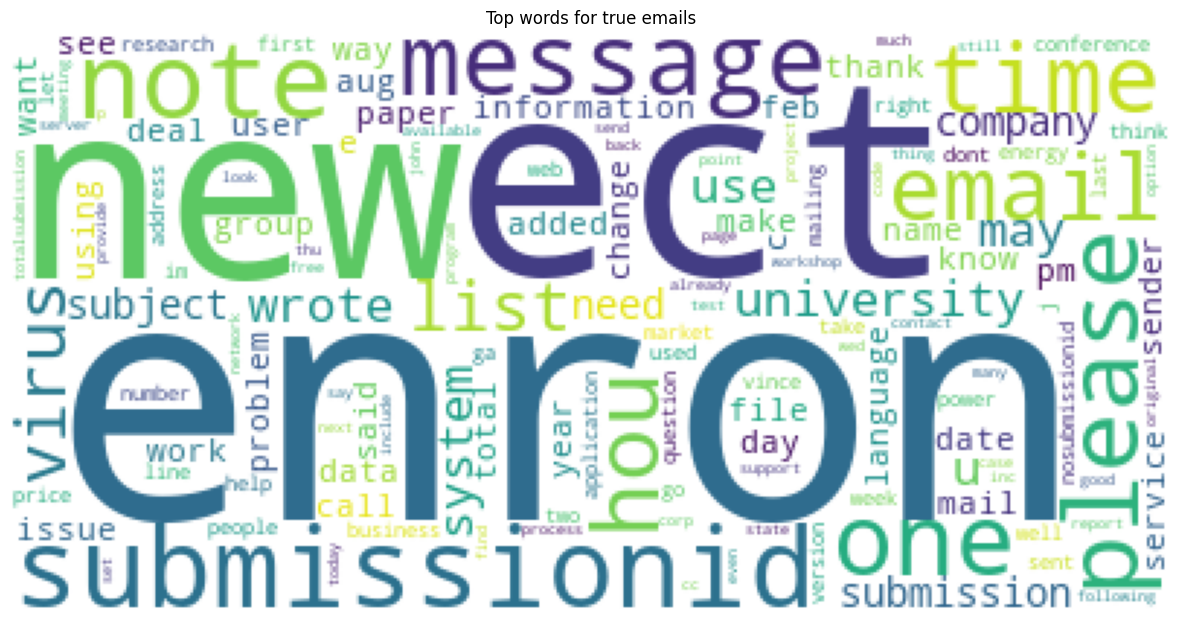

In [123]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

(-0.5, 399.5, 199.5, -0.5)

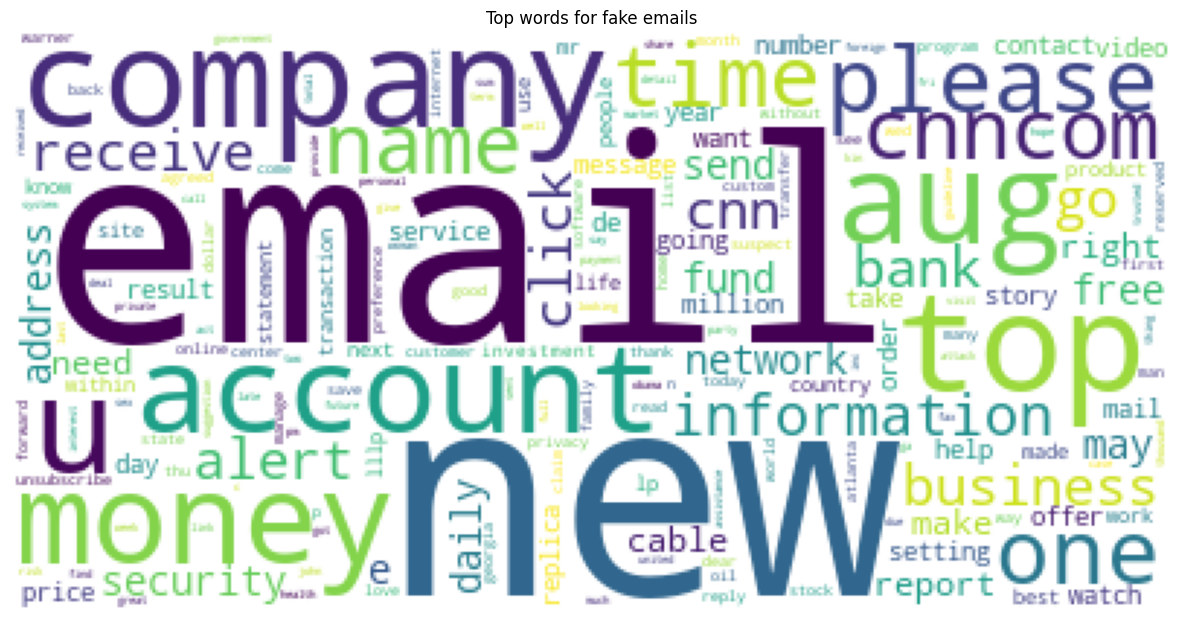

In [124]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

100%|██████████| 85782/85782 [00:00<00:00, 577365.63it/s]


Text(0.5, 1.0, 'KDE plot')

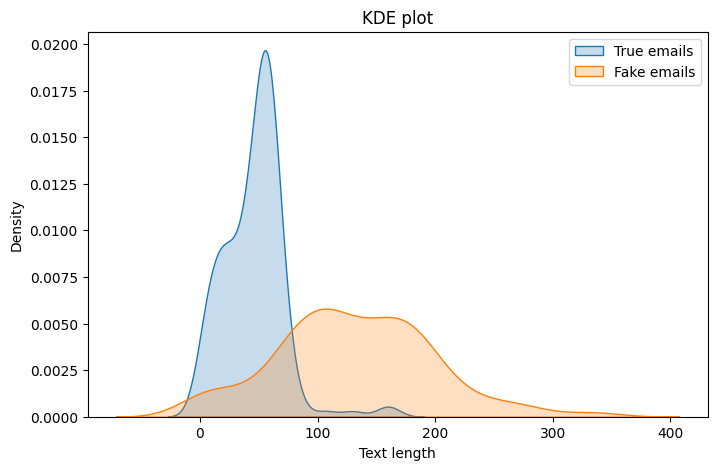

In [149]:

data = np.random.normal(loc=50, scale=15, size=1000) 







plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='True emails')  
sns.kdeplot(fake_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Text length")
plt.ylabel("Density")
plt.title("KDE plot")


### Zipf law

In [156]:
set(true_words)

{'',
 'cantest',
 'itoolsrss',
 'bradstreet',
 'tigerbased',
 'cumul',
 'completement',
 'httpswwwietforgmailmanlistinfoasrg',
 'austinyaxin',
 'catchupa',
 'wiadomosc',
 'sometimesrepellent',
 'nabblecomhifor',
 'understaood',
 'workhbo',
 'eqkvbnmasseyacnzthankget',
 'rpetti',
 'clamavplugin',
 'originatingip',
 'intreprxsplit',
 'madsenwednesday',
 'gordani',
 'maximium',
 'rdnsnewsletteroreillycom',
 'computerconnected',
 'anddepending',
 'openmсpytraceback',
 'anunderlying',
 'httpwwwintelcomtechnologytechresearchpeoplebiosdashdhtm',
 'thatcommissioner',
 'fewerpeople',
 'careerassessment',
 'broking',
 'sporadically',
 'dise',
 'stepinstructions',
 'omigod',
 'spellcheckharlan',
 'sylvana',
 'winnershttpwwwcnetcominlinvrhcwingif',
 'amongresearchers',
 'gyeongnamkr',
 'hen',
 'conocojanie',
 'increaseour',
 'neocortexvirginia',
 'dielectophoresis',
 'areshowingtomwrotei',
 'biokovohercegde',
 'indexeducational',
 'bathwater',
 'activephreakers',
 'forgivenessof',
 'twentyeight',


In [171]:
def count_dict(data):
    words=''.join(text for text in data['body']).split(' ')
    word_counts={}
    for word in tqdm((words)):
        word_counts[word]=word_counts.get(word,0) + 1
    word_counts.pop('')
    return word_counts
true_word_count=count_dict(true_df)
fake_word_count=count_dict(fake_df)

100%|██████████| 11630294/11630294 [00:02<00:00, 4871447.39it/s]


In [176]:
np.arange

<function numpy.arange>

In [181]:
max(true_word_count)

'��������������������������'

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

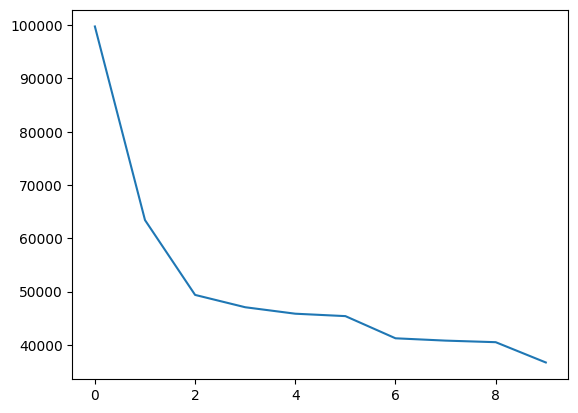

In [180]:
plt.plot(list(sorted(true_word_count.values(),reverse=True))[:10])
plt.plot([max(true_word_count)/x for x in np.arange(10)[1:]])
plt.show()
plt.plot(list(sorted(fake_word_count.values(),reverse=True))[:10])

